<a href="https://colab.research.google.com/github/Aqsa-K/donut-colab-notebook/blob/testing-overfitting/Fine_tune_Donut_on_1880.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set-up environment

First, let's install the relevant libraries:
* 🤗 Transformers, for the model
* 🤗 Datasets, for loading + processing the data
* PyTorch Lightning, for training the model
* Weights and Biases, for logging metrics during training
* Sentencepiece, used for tokenization.

We'll use PyTorch Lightning for training here, but note that this is optional, you can of course also just train in native PyTorch or use 🤗 Accelerate, or the 🤗 Trainer.

In [1]:
!pip install -q transformers datasets sentencepiece

In [2]:
!pip install -q pytorch-lightning wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 57.5 MB/s eta 0:00:00


In [3]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.


In [4]:
import transformers
import datasets
import sentencepiece

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("sentencepiece:", sentencepiece.__version__)

transformers: 4.52.2
datasets: 3.6.0
sentencepiece: 0.2.0


In [5]:
import pytorch_lightning
import wandb
print("pytorch-lightning:", pytorch_lightning.__version__)

print("wandb:", wandb.__version__)

pytorch-lightning: 2.5.1.post0
wandb: 0.19.11


## Load dataset

Next, let's load the dataset from the [hub](https://huggingface.co/datasets/naver-clova-ix/cord-v2). The dataset consists of (image, JSON) pairs. Note that it doesn't have to be JSON, it could also be JSON lines, plain text, etc.

In [6]:
dataset_name_hf = "AqsaK/testdataHW2"

In [7]:
from datasets import load_dataset

# dataset = load_dataset("AqsaK/1880_census_handwritten_archives")
# dataset = load_dataset("naver-clova-ix/cord-v2")
# dataset = load_dataset(dataset_name_hf, split='train[:5%]')
dataset = load_dataset(dataset_name_hf)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.32k [00:00<?, ?B/s]

train.parquet:   0%|          | 0.00/164M [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/20.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/150 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/150 [00:00<?, ? examples/s]

In [8]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 150
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 150
    })
})

Let's take a look at the first training example:

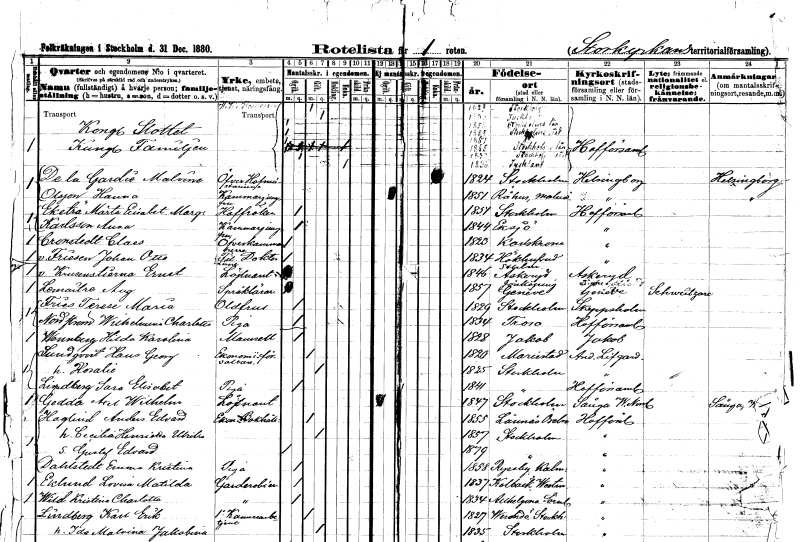

In [9]:
example = dataset['train'][0]
image = example['image']
# let's make the image a bit smaller when visualizing
width, height = image.size
display(image)

In [10]:
print(width, height)

800 542


In [11]:
# let's load the corresponding JSON dictionary (as string representation)
ground_truth = example['ground_truth']
print(ground_truth)

{"gt_parse": {"households": {"individuals": [{"FN": "Oscar II Fredrik"}, {"FN": "Sophia Vilhelmina Mariana Henrietta"}, {"FN": "Gustaf Oscar Adolf"}, {"FN": "Oscar Carl August"}, {"FN": "Carl Oscar Vilhelm"}, {"FN": "Eug\u00e9n Napoleon Nicolaus"}, {"FN": "Charlotta Eugenia Augusta Amalia Albertina"}, {"FN": "Th\u00e9r\u00e8se Amalie Josephine Antoinette"}, {"FN": "Malvina", "EN": "De la Gardie"}, {"FN": "Hanna", "EN": "Olsson"}, {"FN": "M\u00e4rta Elisabet Margreta", "EN": "Eketr\u00e4"}, {"FN": "Anna", "EN": "Karlsson"}, {"FN": "Claes", "EN": "Cronstedt"}, {"FN": "Johan Otto", "EN": "v. Frisen"}, {"FN": "Ernst", "EN": "v. Krusenstjerna"}, {"FN": "August", "EN": "Lemaitre"}, {"FN": "Terese Maria", "EN": "Fries"}, {"FN": "Wilhelmina Charlotta", "EN": "Nordstr\u00f6m"}, {"FN": "Hilda Karolina", "EN": "Wennberg"}, {"FN": "Hans Georg", "EN": "Lundqvist"}, {"FN": "Rosalie"}, {"FN": "Sara Elisabet", "EN": "Lindberg"}, {"FN": "Axel Wilhelm", "EN": "Gedda"}, {"FN": "Anders Edvard", "EN": "Hag

We can also parse the string as a Python dictionary using `ast.literal_eval`. Each training example has a single "gt_parse" key, which contains the ground truth parsing of the document:

In [12]:
from ast import literal_eval

literal_eval(ground_truth)['gt_parse']

{'households': {'individuals': [{'FN': 'Oscar II Fredrik'},
   {'FN': 'Sophia Vilhelmina Mariana Henrietta'},
   {'FN': 'Gustaf Oscar Adolf'},
   {'FN': 'Oscar Carl August'},
   {'FN': 'Carl Oscar Vilhelm'},
   {'FN': 'Eugén Napoleon Nicolaus'},
   {'FN': 'Charlotta Eugenia Augusta Amalia Albertina'},
   {'FN': 'Thérèse Amalie Josephine Antoinette'},
   {'FN': 'Malvina', 'EN': 'De la Gardie'},
   {'FN': 'Hanna', 'EN': 'Olsson'},
   {'FN': 'Märta Elisabet Margreta', 'EN': 'Eketrä'},
   {'FN': 'Anna', 'EN': 'Karlsson'},
   {'FN': 'Claes', 'EN': 'Cronstedt'},
   {'FN': 'Johan Otto', 'EN': 'v. Frisen'},
   {'FN': 'Ernst', 'EN': 'v. Krusenstjerna'},
   {'FN': 'August', 'EN': 'Lemaitre'},
   {'FN': 'Terese Maria', 'EN': 'Fries'},
   {'FN': 'Wilhelmina Charlotta', 'EN': 'Nordström'},
   {'FN': 'Hilda Karolina', 'EN': 'Wennberg'},
   {'FN': 'Hans Georg', 'EN': 'Lundqvist'},
   {'FN': 'Rosalie'},
   {'FN': 'Sara Elisabet', 'EN': 'Lindberg'},
   {'FN': 'Axel Wilhelm', 'EN': 'Gedda'},
   {'FN': '

In [13]:
import json
name_tokens = set()
# get all names and add them as tokens
for item in dataset["train"]:
    sample = json.loads(item["ground_truth"]) #["gt_parse"]
    print(sample)
    people = sample["gt_parse"]["households"]["individuals"]

    for person in people:
      if "FN" in person.keys():
        for token in person["FN"].split():
            name_tokens.add(token)
      if "EN" in person.keys():
        for token in person["EN"].split():
          name_tokens.add(token)
    # break
# Add new tokens
# name_tokens = ["Carl", "Gustaf", "Sven", "Axel", "Clara", "Edvard", "Ludvig", "Gustavva"]
# added = processor.tokenizer.add_tokens(name_tokens)

# # Resize the model's embeddings
# model.decoder.resize_token_embeddings(len(processor.tokenizer))

{'gt_parse': {'households': {'individuals': [{'FN': 'Oscar II Fredrik'}, {'FN': 'Sophia Vilhelmina Mariana Henrietta'}, {'FN': 'Gustaf Oscar Adolf'}, {'FN': 'Oscar Carl August'}, {'FN': 'Carl Oscar Vilhelm'}, {'FN': 'Eugén Napoleon Nicolaus'}, {'FN': 'Charlotta Eugenia Augusta Amalia Albertina'}, {'FN': 'Thérèse Amalie Josephine Antoinette'}, {'FN': 'Malvina', 'EN': 'De la Gardie'}, {'FN': 'Hanna', 'EN': 'Olsson'}, {'FN': 'Märta Elisabet Margreta', 'EN': 'Eketrä'}, {'FN': 'Anna', 'EN': 'Karlsson'}, {'FN': 'Claes', 'EN': 'Cronstedt'}, {'FN': 'Johan Otto', 'EN': 'v. Frisen'}, {'FN': 'Ernst', 'EN': 'v. Krusenstjerna'}, {'FN': 'August', 'EN': 'Lemaitre'}, {'FN': 'Terese Maria', 'EN': 'Fries'}, {'FN': 'Wilhelmina Charlotta', 'EN': 'Nordström'}, {'FN': 'Hilda Karolina', 'EN': 'Wennberg'}, {'FN': 'Hans Georg', 'EN': 'Lundqvist'}, {'FN': 'Rosalie'}, {'FN': 'Sara Elisabet', 'EN': 'Lindberg'}, {'FN': 'Axel Wilhelm', 'EN': 'Gedda'}, {'FN': 'Anders Edvard', 'EN': 'Haglind'}, {'FN': 'Cecilia Henrik

In [14]:
len(name_tokens)

6569

In [13]:
max_length = 0
for item in dataset["train"]:
    sample = item["ground_truth"] #["gt_parse"]
    # print(sample)
    est_length = int(len(str(sample)))
    if est_length > max_length:
        max_length = est_length
    break

max_length

1199

In [ ]:
# max_length = 14811

In [14]:
max_width = 0
max_height = 0
for item in dataset["test"]:
    image = item["image"] #["gt_parse"]
    width, height = image.size
    # print(width, height)
    if width > max_width:
        max_width = width
    if height > max_height:
        max_height = height

print(max_width, max_height)


800 608


## Load model and processor

Next, we load the model (Donut is an instance of [VisionEncoderDecoderModel](https://huggingface.co/docs/transformers/model_doc/vision-encoder-decoder)), and the processor, which is the object that can be used to prepare inputs for the model.

We'll update some settings for fine-tuning, namely the image size and the max length of the decoder.

In [57]:
from transformers import VisionEncoderDecoderConfig

# image_size = [1280, 960] #for naver clova dataset
image_size = [max_height, max_width] # for census data

max_length = max_length #14811

# update image_size of the encoder
# during pre-training, a larger image size was used
config = VisionEncoderDecoderConfig.from_pretrained("naver-clova-ix/donut-base")
config.encoder.image_size = image_size # (height, width)
# update max_length of the decoder (for generation)
config.decoder.max_length = max_length
# TODO we should actually update max_position_embeddings and interpolate the pre-trained ones:
# https://github.com/clovaai/donut/blob/0acc65a85d140852b8d9928565f0f6b2d98dc088/donut/model.py#L602

In [61]:
assert config.decoder.max_length <= config.decoder.max_position_embeddings

Next, we instantiate the model with our custom config, as well as the processor. Make sure that all pre-trained weights are correctly loaded (a warning would tell you if that's not the case).

In [18]:
1000/1800


0.5555555555555556

In [16]:
from transformers import DonutProcessor, VisionEncoderDecoderModel

pretrained_hf_model = "naver-clova-ix/donut-base"
# pretrained_hf_model = "AqsaK/donut_cord"

processor = DonutProcessor.from_pretrained(pretrained_hf_model)
model = VisionEncoderDecoderModel.from_pretrained(pretrained_hf_model, config=config)

processor.feature_extractor.size = image_size

preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.30M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.01M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/71.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/355 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/809M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/donut/processing_donut.py:217: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(


In [17]:
print("Special tokens map:")
print(processor.tokenizer.special_tokens_map)


Special tokens map:
{'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>', 'additional_special_tokens': ['<s_iitcdip>', '<s_synthdog>']}


In [ ]:
# Add new tokens
# added = processor.tokenizer.add_tokens(list(name_tokens))

# # Resize the model's embeddings
# model.decoder.resize_token_embeddings(len(processor.tokenizer))

In [ ]:
# processor.feature_extractor.do_resize = True
# processor.feature_extractor.size = 1600
# processor.feature_extractor.resample = <interpolation_method>
# processor.feature_extractor.do_align_long_axis = True

## Create PyTorch dataset

Here we create a regular PyTorch dataset.

The model doesn't directly take the (image, JSON) pairs as input and labels. Rather, we create `pixel_values` and `labels`. Both are PyTorch tensors. The `pixel_values` are the input images (resized, padded and normalized), and the `labels` are the `input_ids` of the target sequence (which is a flattened version of the JSON), with padding tokens replaced by -100 (to make sure these are ignored by the loss function). Both are created using `DonutProcessor` (which internally combines an image processor, for the image modality, and a tokenizer, for the text modality).

Note that we're also adding tokens to the vocabulary of the decoder (and corresponding tokenizer) for all keys of the dictionaries in our dataset, like "\<s_menu>". This makes sure the model learns an embedding vector for them. Without doing this, some keys might get split up into multiple subword tokens, in which case the model just learns an embedding for the subword tokens, rather than a direct embedding for these keys.

In [62]:
import json
import random
from typing import Any, List, Tuple

import torch
from torch.utils.data import Dataset

from PIL import Image, UnidentifiedImageError

from PIL import Image
import io

added_tokens = []

class DonutDataset(Dataset):
    """
    PyTorch Dataset for Donut. This class takes a HuggingFace Dataset as input.

    Each row, consists of image path(png/jpg/jpeg) and gt data (json/jsonl/txt),
    and it will be converted into pixel_values (vectorized image) and labels (input_ids of the tokenized string).

    Args:
        dataset_name_or_path: name of dataset (available at huggingface.co/datasets) or the path containing image files and metadata.jsonl
        max_length: the max number of tokens for the target sequences
        split: whether to load "train", "validation" or "test" split
        ignore_id: ignore_index for torch.nn.CrossEntropyLoss
        task_start_token: the special token to be fed to the decoder to conduct the target task
        prompt_end_token: the special token at the end of the sequences
        sort_json_key: whether or not to sort the JSON keys
    """

    def __init__(
        self,
        dataset_name_or_path: str,
        max_length: int,
        split: str = "train",
        ignore_id: int = -100,
        task_start_token: str = "<s>",
        prompt_end_token: str = None,
        sort_json_key: bool = True,
    ):
        super().__init__()

        self.max_length = max_length
        self.split = split
        self.ignore_id = ignore_id
        self.task_start_token = task_start_token
        self.prompt_end_token = prompt_end_token if prompt_end_token else task_start_token
        self.sort_json_key = sort_json_key

        self.dataset = load_dataset(dataset_name_or_path, split=self.split)
        self.dataset_length = len(self.dataset)

        print(self.dataset_length)

        k= 0

        self.gt_token_sequences = []
        self.valid_indices = []  # Store valid indices

        for i in range(self.dataset_length):
            try:
              sample = self.dataset[i]
              # print(k)
              # print(sample)
              ground_truth = json.loads(sample["ground_truth"])
              if "gt_parses" in ground_truth:  # when multiple ground truths are available, e.g., docvqa
                  assert isinstance(ground_truth["gt_parses"], list)
                  gt_jsons = ground_truth["gt_parses"]
                  # print("gt parses added successfully")
              else:
                  assert "gt_parse" in ground_truth and isinstance(ground_truth["gt_parse"], dict)
                  gt_jsons = [ground_truth["gt_parse"]]
                  # print("gt parse added successfully")


              self.gt_token_sequences.append(
                  [
                      self.json2token(
                          gt_json,
                          update_special_tokens_for_json_key=self.split == "train",
                          sort_json_key=self.sort_json_key,
                      )
                      # + processor.tokenizer.eos_token
                      for gt_json in gt_jsons  # load json from list of json
                  ]
              )
              self.valid_indices.append(i) # Add valid index
              # break
            except Exception as e:
              print(f"Skipping bad image: {e}")
              k+=1
              continue
            # k+=1
            # if k > 50:
            #   break

        self.add_tokens([self.task_start_token, self.prompt_end_token])
        self.prompt_end_token_id = processor.tokenizer.convert_tokens_to_ids(self.prompt_end_token)

    def json2token(self, obj: Any, update_special_tokens_for_json_key: bool = True, sort_json_key: bool = True):
        """
        Convert an ordered JSON object into a token sequence
        """
        if type(obj) == dict:
            # print("inside json2token if")
            if len(obj) == 1 and "text_sequence" in obj:
                return obj["text_sequence"]
            else:
                output = ""
                if sort_json_key:
                    keys = sorted(obj.keys(), reverse=True)
                else:
                    keys = obj.keys()
                for k in keys:
                    # print("key: ", k)
                    if update_special_tokens_for_json_key:
                        # print("adding token")
                        self.add_tokens([fr"<s_{k}>", fr"</s_{k}>"])
                    output += (
                        fr"<s_{k}>"
                        + self.json2token(obj[k], update_special_tokens_for_json_key, sort_json_key)
                        + fr"</s_{k}>"
                    )
                # print("output: ", output)
                return output
        elif type(obj) == list:
            return r"<sep/>".join(
                [self.json2token(item, update_special_tokens_for_json_key, sort_json_key) for item in obj]
            )
        else:
            obj = str(obj)
            if f"<{obj}/>" in added_tokens:
                obj = f"<{obj}/>"  # for categorical special tokens
            return obj

    def add_tokens(self, list_of_tokens: List[str]):
        """
        Add special tokens to tokenizer and resize the token embeddings of the decoder
        """
        # print("inside add token function: ", list_of_tokens)
        special_tokens_dict = {"additional_special_tokens": list_of_tokens}
        newly_added_num = processor.tokenizer.add_special_tokens(special_tokens_dict)
        # print("newly_added_num: ", newly_added_num)

        if newly_added_num > 0:
            # print("token added to token list")
            # print("added tokens: ", list_of_tokens)
            model.decoder.resize_token_embeddings(len(processor.tokenizer))
            added_tokens.extend(list_of_tokens)

    def __len__(self) -> int:
        return len(self.valid_indices)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Load image from image_path of given dataset_path and convert into input_tensor and labels
        Convert gt data into input_ids (tokenized string)
        Returns:
            input_tensor : preprocessed image
            input_ids : tokenized gt_data
            labels : masked labels (model doesn't need to predict prompt and pad token)
        """
        # Use the valid index to access the original dataset
        true_idx = self.valid_indices[idx]
        sample = self.dataset[true_idx]
        # sample = self.dataset[idx]

        # # inputs
        # # Check if image data is valid before attempting to open:
        # image_bytes = sample["image"].tobytes()
        # if not image_bytes:  # or len(image_bytes) < 100:  # Add a size check if needed
        #     raise ValueError(f"Invalid image data at index {idx}")

        # # Open image using Pillow with format hint (if available):
        # try:
        #     image = Image.open(io.BytesIO(image_bytes)).convert("RGB")  # Explicitly convert to RGB
        # except UnidentifiedImageError:
        #     # Handle the error, e.g., skip the sample, replace with a placeholder image, etc.
        #     print(f"WARNING: Could not open image at index {idx}, skipping...")
        #     return None  # Or handle differently
        # pixel_values = processor(image, random_padding=self.split == "train", return_tensors="pt").pixel_values
        # pixel_values = pixel_values.squeeze()

        # inputs
        pixel_values = processor(sample["image"].convert("RGB"), random_padding=self.split == "train", return_tensors="pt").pixel_values
        pixel_values = pixel_values.squeeze()

        # targets
        target_sequence = random.choice(self.gt_token_sequences[idx])  # can be more than one, e.g., DocVQA Task 1
        full_sequence = self.task_start_token + target_sequence + self.prompt_end_token

        input_ids = processor.tokenizer(
            full_sequence,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )["input_ids"].squeeze(0)

        labels = input_ids.clone()
        labels[labels == processor.tokenizer.pad_token_id] = self.ignore_id  # model doesn't need to predict pad token
        # labels[: torch.nonzero(labels == self.prompt_end_token_id).sum() + 1] = self.ignore_id  # model doesn't need to predict prompt (for VQA)
        return pixel_values, labels, full_sequence

Next, we instantiate the datasets:

In [63]:
# we update some settings which differ from pretraining; namely the size of the images + no rotation required
# source: https://github.com/clovaai/donut/blob/master/config/train_cord.yaml
processor.image_processor.size = image_size[::-1] # should be (width, height)
processor.image_processor.do_align_long_axis = False

train_dataset = DonutDataset(dataset_name_hf, max_length=max_length,
                             split="train", task_start_token="<s_arch-v1>", prompt_end_token="</s_arch-v1>",
                             sort_json_key=False, # cord dataset is preprocessed, so no need for this
                             )

# val_dataset = DonutDataset("naver-clova-ix/cord-v2", max_length=max_length,
#                              split="validation", task_start_token="<s_cord-v2>", prompt_end_token="<s_cord-v2>",
#                              sort_json_key=False, # cord dataset is preprocessed, so no need for this
#                              )


val_dataset = DonutDataset(dataset_name_hf, max_length=max_length,
                             split="validation", task_start_token="<s_arch-v1>", prompt_end_token="</s_arch-v1>",
                             sort_json_key=False, # cord dataset is preprocessed, so no need for this
                             )



# train_dataset = DonutDataset("naver-clova-ix/cord-v2", max_length=max_length,
#                              split="train", task_start_token="<s_cord-v2>", prompt_end_token="<s_cord-v2>",
#                              sort_json_key=False, # cord dataset is preprocessed, so no need for this
#                              )

# val_dataset = DonutDataset("naver-clova-ix/cord-v2", max_length=max_length,
#                              split="validation", task_start_token="<s_cord-v2>", prompt_end_token="<s_cord-v2>",
#                              sort_json_key=False, # cord dataset is preprocessed, so no need for this
#                              )

1200
150


In [64]:
print("Additional special tokens:")
print(processor.tokenizer.additional_special_tokens)

Additional special tokens:
['<s_arch-v1>', '</s_arch-v1>']


In [65]:
print("Special tokens map:")
print(processor.tokenizer.special_tokens_map)


Special tokens map:
{'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>', 'additional_special_tokens': ['<s_arch-v1>', '</s_arch-v1>']}


In [66]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch

def show_random_samples(dataset, num_samples=3):
    indices = random.sample(range(len(dataset)), num_samples)

    for idx in indices:
        pixel_values, _, label_text = dataset[idx]

        # Convert pixel_values from [-1, 1] to [0, 255] and to PIL Image
        if isinstance(pixel_values, torch.Tensor):
            img = pixel_values.clone().detach()
            img = ((img + 1) / 2.0 * 255).clamp(0, 255)  # scale to [0, 255]
            img = img.permute(1, 2, 0).cpu().numpy().astype("uint8")
            img = Image.fromarray(img)
            print(img.size)

        else:
            raise ValueError("pixel_values is not a torch.Tensor")

        # Show image
        plt.figure(figsize=(20,20))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Sample Index: {idx}")
        plt.show()

        # Print associated label
        print(f"\n📄 Label for Sample {idx}:\n{label_text}\n")


(800, 608)


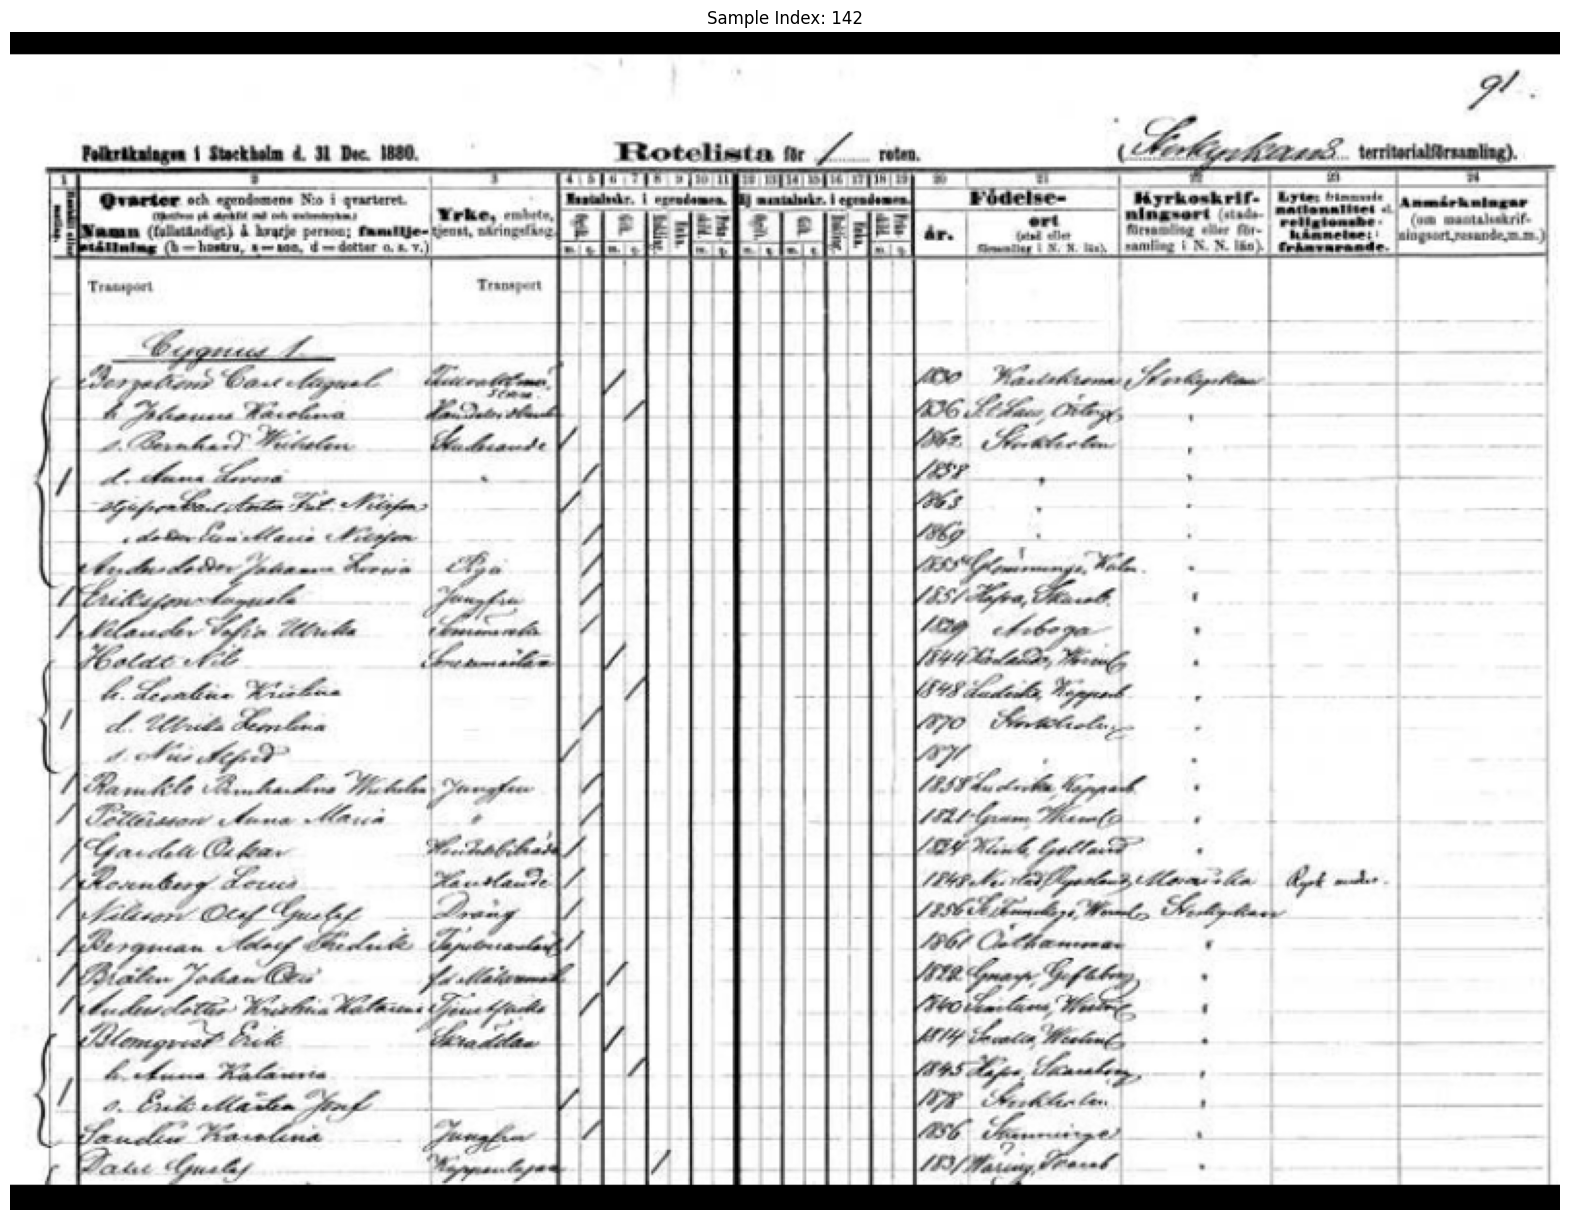


📄 Label for Sample 142:
<s_arch-v1><s_households><s_individuals><s_FN>Carl August</s_FN><s_EN>Bergström</s_EN><sep/><s_FN>Johanna Karolina</s_FN><sep/><s_FN>Bernhard Wilhelm</s_FN><sep/><s_FN>Anna Lovisa</s_FN><sep/><s_FN>Carl Anton Fritiof</s_FN><s_EN>Nilsson</s_EN><sep/><s_FN>Elin Maria</s_FN><s_EN>Nilsson</s_EN><sep/><s_FN>Johanna Lovisa</s_FN><s_EN>Andersdotter</s_EN><sep/><s_FN>Augusta</s_FN><s_EN>Eriksson</s_EN><sep/><s_FN>Sofia Ulrika</s_FN><s_EN>Nelander</s_EN><sep/><s_FN>Nils</s_FN><s_EN>Holdt</s_EN><sep/><s_FN>Leontina Kristina</s_FN><sep/><s_FN>Ulrika Leontina</s_FN><sep/><s_FN>Nils Alfred</s_FN><sep/><s_FN>Bernhardina Wilhelmina</s_FN><s_EN>Ramklo</s_EN><sep/><s_FN>Anna Maria</s_FN><s_EN>Pettersson</s_EN><sep/><s_FN>Oskar</s_FN><s_EN>Gardell</s_EN><sep/><s_FN>Louis</s_FN><s_EN>Rosenberg</s_EN><sep/><s_FN>Olof Gustaf</s_FN><s_EN>Nilsson</s_EN><sep/><s_FN>Adolf Fredrik</s_FN><s_EN>Bergman</s_EN><sep/><s_FN>Johan Otto</s_FN><s_EN>Bråten</s_EN><sep/><s_FN>Kristina Katarina</s_

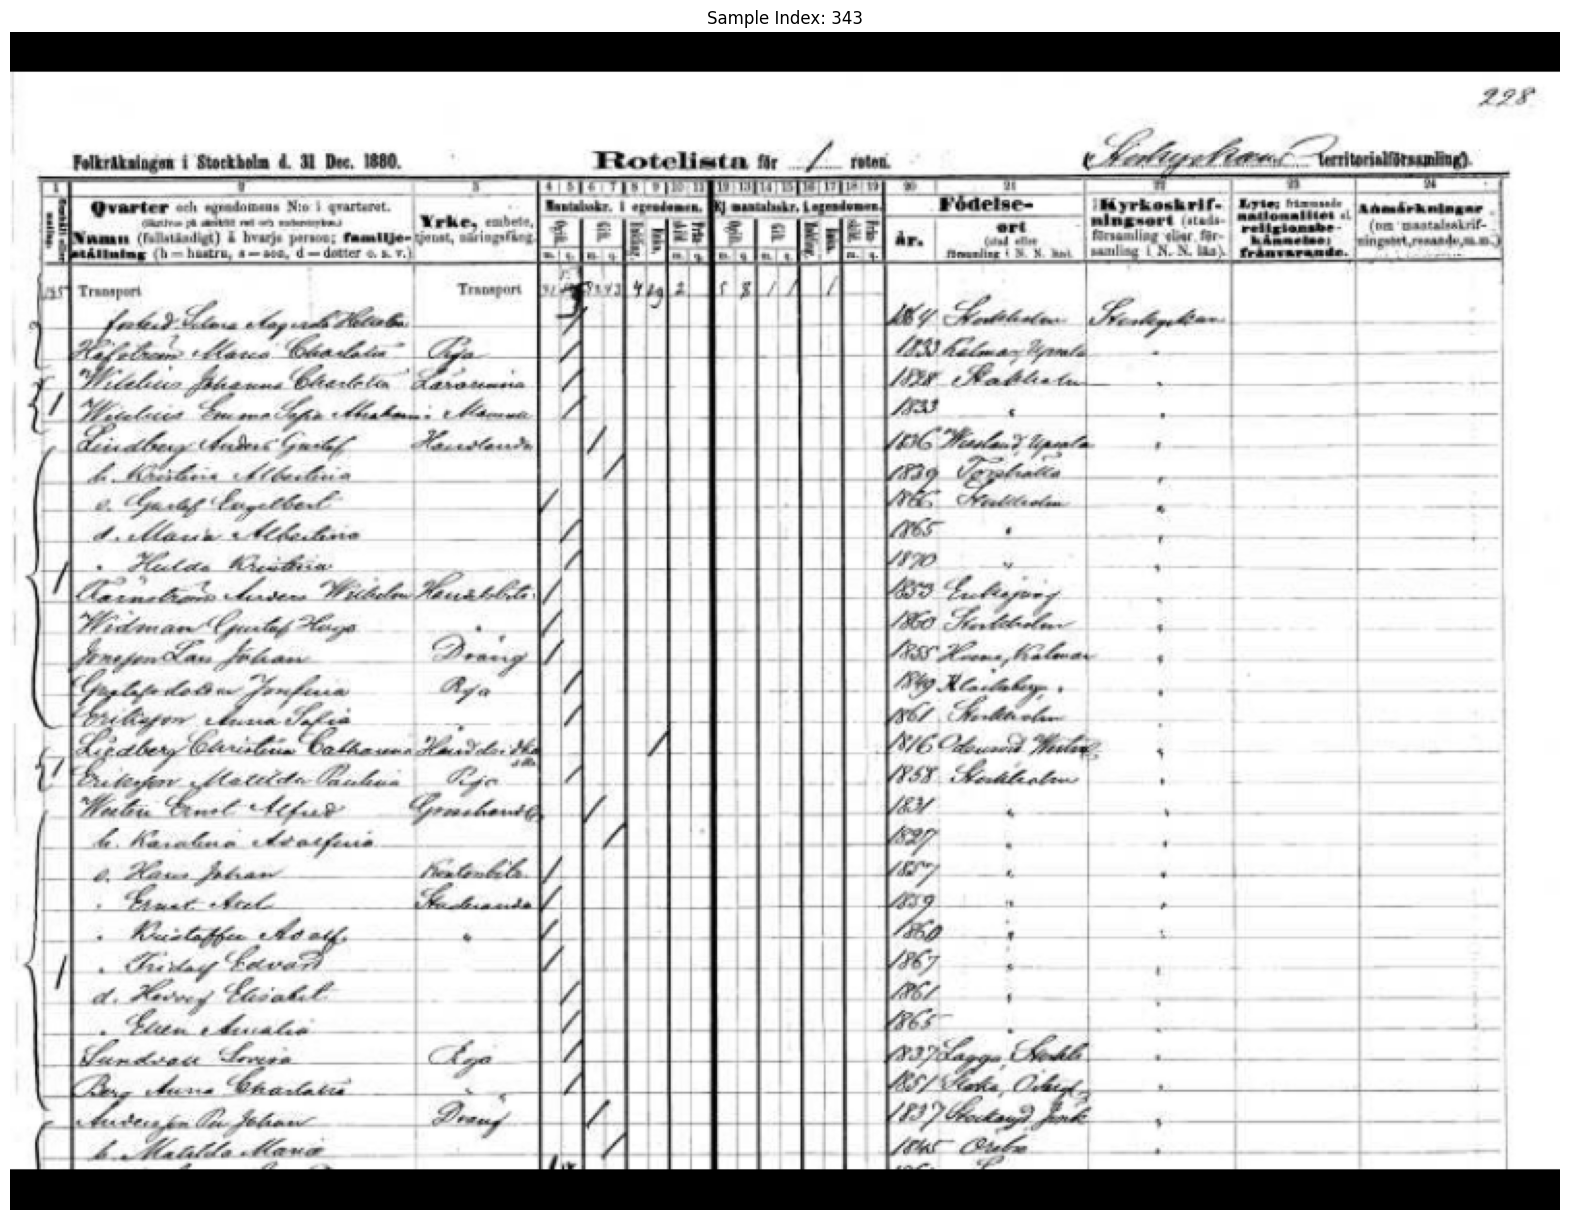


📄 Label for Sample 343:
<s_arch-v1><s_households><s_individuals><s_FN>Selma Augusta</s_FN><s_EN>Hellsten</s_EN><sep/><s_FN>Maria Charlotta</s_FN><s_EN>Häfström</s_EN><sep/><s_FN>Johanna Charlotta</s_FN><s_EN>Wihlius</s_EN><sep/><s_FN>Emma Sofia Abrahamina</s_FN><s_EN>Wihlius</s_EN><sep/><s_FN>Anders Gustaf</s_FN><s_EN>Lindberg</s_EN><sep/><s_FN>Kristina Albertina</s_FN><sep/><s_FN>Gustaf Engelbert</s_FN><sep/><s_FN>Maria Albertina</s_FN><sep/><s_FN>Hulda Kristina</s_FN><sep/><s_FN>Anders Wilhelm</s_FN><s_EN>Färnström</s_EN><sep/><s_FN>Gustaf Hugo</s_FN><s_EN>Widman</s_EN><sep/><s_FN>Lars Johan</s_FN><s_EN>Jonsson</s_EN><sep/><s_FN>Josefina</s_FN><s_EN>Gustafsdotter</s_EN><sep/><s_FN>Anna Sofia</s_FN><s_EN>Eriksson</s_EN><sep/><s_FN>Christina Catharina</s_FN><s_EN>Liedberg</s_EN><sep/><s_FN>Matilda Paulina</s_FN><s_EN>Eriksson</s_EN><sep/><s_FN>Ernst Alfred</s_FN><s_EN>Wester</s_EN><sep/><s_FN>Karolina Adolfina</s_FN><sep/><s_FN>Hans Johan</s_FN><sep/><s_FN>Ernst Axel</s_FN><sep/><s_FN

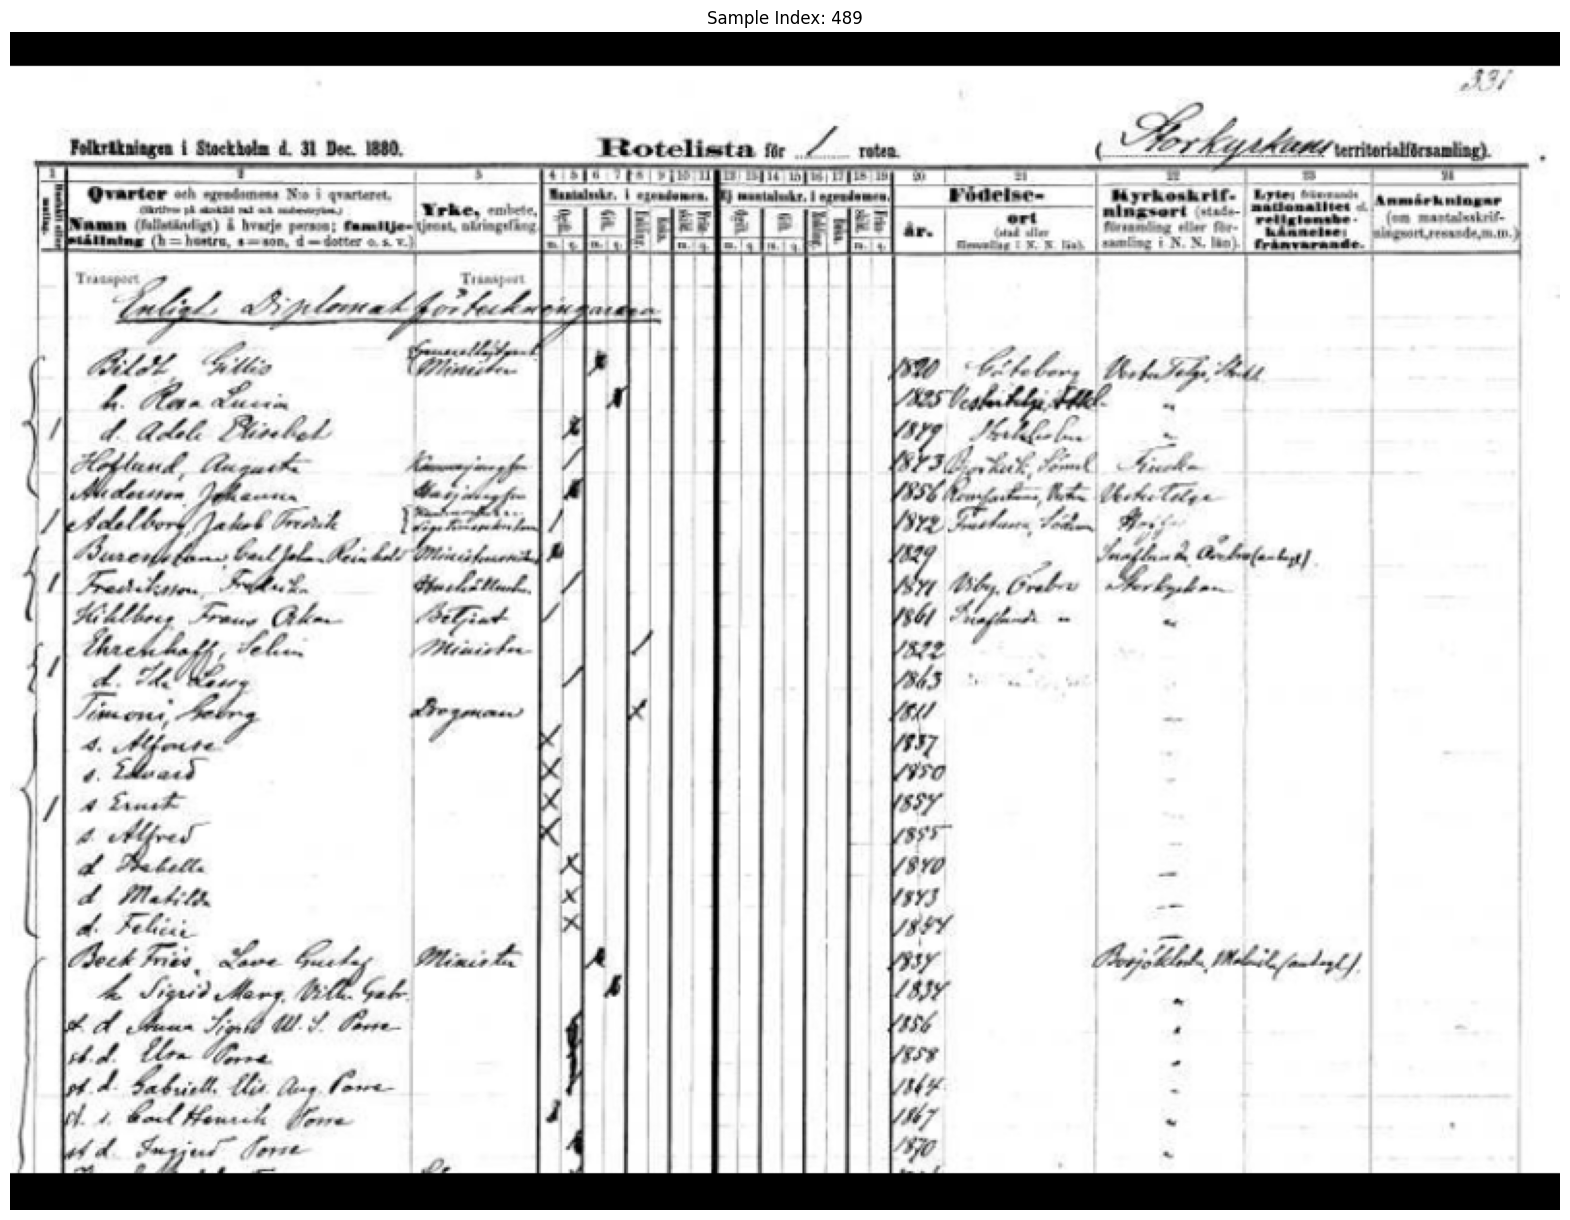


📄 Label for Sample 489:
<s_arch-v1><s_households><s_individuals><s_FN>Gillis</s_FN><s_EN>Bildt</s_EN><sep/><s_FN>Rosa Lucia</s_FN><sep/><s_FN>Adele Elisabet</s_FN><sep/><s_FN>Augusta</s_FN><s_EN>Hoflund</s_EN><sep/><s_FN>Johanna</s_FN><s_EN>Andersson</s_EN><sep/><s_FN>Jakob Fredrik</s_FN><s_EN>Adelborg</s_EN><sep/><s_FN>Carl Johan Reinhold</s_FN><s_EN>Burenstam</s_EN><sep/><s_FN>Fredrika</s_FN><s_EN>Fredriksson</s_EN><sep/><s_FN>Frans Oskar</s_FN><s_EN>Kihlberg</s_EN><sep/><s_FN>Selin</s_FN><s_EN>Ehrenhoff</s_EN><sep/><s_FN>Ida Lessy</s_FN><sep/><s_FN>Georg</s_FN><s_EN>Tomoni</s_EN><sep/><s_FN>Alfonse</s_FN><sep/><s_FN>Edvard</s_FN><sep/><s_FN>Ernst</s_FN><sep/><s_FN>Alfred</s_FN><sep/><s_FN>Isabella</s_FN><sep/><s_FN>Matilda</s_FN><sep/><s_FN>Felicie</s_FN><sep/><s_FN>Lave Gustaf</s_FN><s_EN>Beck Fries</s_EN><sep/><s_FN>Sigrid Margareta Vilhelmina Gabriella</s_FN><sep/><s_FN>Anna Sigrid W. S.</s_FN><s_EN>Posse</s_EN><sep/><s_FN>Elsa</s_FN><s_EN>Posse</s_EN><sep/><s_FN>Gabriella Elisa

In [67]:
show_random_samples(train_dataset, 3)

In [68]:
from torch.utils.data import Subset
# Create a subset of the first 100 samples
val_dataset = Subset(val_dataset, indices=list(range(5)))
train_dataset = Subset(train_dataset, indices=list(range(10)))

Let's check which tokens are added:

In [69]:
len(added_tokens)


0

In [70]:
print(added_tokens)

[]


In [71]:
# the vocab size attribute stays constants (might be a bit unintuitive - but doesn't include special tokens)
print("Original number of tokens:", processor.tokenizer.vocab_size)
print("Number of tokens after adding special tokens:", len(processor.tokenizer))

Original number of tokens: 57522
Number of tokens after adding special tokens: 57535


In [72]:
sample = val_dataset[0]
image_tensor, labels_tensor, prompt_text = sample

print("Prompt text:", prompt_text)

assert prompt_text.startswith("<s_arch-v1>"), "Missing start token!"



Prompt text: <s_arch-v1><s_households><s_individuals><s_FN>Johan</s_FN><s_EN>Johansson</s_EN><sep/><s_FN>Anna Maria</s_FN><sep/><s_FN>Agnes Matilda Josefina</s_FN><sep/><s_FN>Emma Kristina</s_FN><s_EN>Pettersson</s_EN><sep/><s_FN>Sofia Karolina</s_FN><s_EN>Pettersson</s_EN><sep/><s_FN>Erik</s_FN><s_EN>Milström</s_EN><sep/><s_FN>Axel Otto</s_FN><s_EN>Johansson</s_EN><sep/><s_FN>Karl Emil</s_FN><s_EN>Johansson</s_EN></s_individuals></s_households></s_arch-v1>


In [73]:
input_ids = processor.tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
decoded = processor.tokenizer.decode(input_ids, skip_special_tokens=False)

print("Decoded back:", decoded)


Decoded back: <s_arch-v1><s_households><s_individuals><s_FN> Johan</s_FN><s_EN> Johansson</s_EN><sep/><s_FN> Anna Maria</s_FN><sep/><s_FN> Agnes Matilda Josefina</s_FN><sep/><s_FN> Emma Kristina</s_FN><s_EN> Pettersson</s_EN><sep/><s_FN> Sofia Karolina</s_FN><s_EN> Pettersson</s_EN><sep/><s_FN> Erik</s_FN><s_EN> Milström</s_EN><sep/><s_FN> Axel Otto</s_FN><s_EN> Johansson</s_EN><sep/><s_FN> Karl Emil</s_FN><s_EN> Johansson</s_EN></s_individuals></s_households></s_arch-v1>


You can verify that a token like `</s_unitprice>` was added to the vocabulary of the tokenizer (and the model):

In [74]:
processor.decode([70])

'watching'

As always, it's very important to verify whether our data is prepared correctly. Let's check the first training example:

In [75]:
train_dataset[0]

(tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 tensor([57533, 57525, 57527,  ...,  -100,  -100,  -100]),
 '<s_arch-v1><s_househo

In [76]:
pixel_values, labels, target_sequence = train_dataset[0]

This returns the `pixel_values` (the image, but prepared for the model as a PyTorch tensor), the `labels` (which are the encoded `input_ids` of the target sequence, which we want Donut to learn to generate) and the original `target_sequence`. The reason we also return the latter is because this will allow us to compute metrics between the generated sequences and the ground truth target sequences.

In [77]:
print(pixel_values.shape)

torch.Size([3, 608, 800])


In [78]:
# let's print the labels (the first 30 token ID's)
for id in labels.tolist()[:30]:
  if id != -100:
    print(processor.decode([id]))
  else:
    print(id)

<s_arch-v1>
<s_households>
<s_individuals>
<s_FN>
Oscar
II
Fredrik
</s_FN>
<sep/>
<s_FN>
Sop
hia
Vil
hel
mina
Maria
na
Henri
etta
</s_FN>
<sep/>
<s_FN>
G
usta
f
Oscar
A
dol
f
</s_FN>


In [79]:
# let's check the corresponding target sequence, as a string
print(target_sequence)

<s_arch-v1><s_households><s_individuals><s_FN>Oscar II Fredrik</s_FN><sep/><s_FN>Sophia Vilhelmina Mariana Henrietta</s_FN><sep/><s_FN>Gustaf Oscar Adolf</s_FN><sep/><s_FN>Oscar Carl August</s_FN><sep/><s_FN>Carl Oscar Vilhelm</s_FN><sep/><s_FN>Eugén Napoleon Nicolaus</s_FN><sep/><s_FN>Charlotta Eugenia Augusta Amalia Albertina</s_FN><sep/><s_FN>Thérèse Amalie Josephine Antoinette</s_FN><sep/><s_FN>Malvina</s_FN><s_EN>De la Gardie</s_EN><sep/><s_FN>Hanna</s_FN><s_EN>Olsson</s_EN><sep/><s_FN>Märta Elisabet Margreta</s_FN><s_EN>Eketrä</s_EN><sep/><s_FN>Anna</s_FN><s_EN>Karlsson</s_EN><sep/><s_FN>Claes</s_FN><s_EN>Cronstedt</s_EN><sep/><s_FN>Johan Otto</s_FN><s_EN>v. Frisen</s_EN><sep/><s_FN>Ernst</s_FN><s_EN>v. Krusenstjerna</s_EN><sep/><s_FN>August</s_FN><s_EN>Lemaitre</s_EN><sep/><s_FN>Terese Maria</s_FN><s_EN>Fries</s_EN><sep/><s_FN>Wilhelmina Charlotta</s_FN><s_EN>Nordström</s_EN><sep/><s_FN>Hilda Karolina</s_FN><s_EN>Wennberg</s_EN><sep/><s_FN>Hans Georg</s_FN><s_EN>Lundqvist</s_EN>

Another important thing is that we need to set 2 additional attributes in the configuration of the model. This is not required, but will allow us to train the model by only providing the decoder targets, without having to provide any decoder inputs.

The model will automatically create the `decoder_input_ids` (the decoder inputs) based on the `labels`, by shifting them one position to the right and prepending the decoder_start_token_id. I recommend checking [this video](https://www.youtube.com/watch?v=IGu7ivuy1Ag&t=888s&ab_channel=NielsRogge) if you want to understand how models like Donut automatically create decoder_input_ids - and more broadly how Donut works.

In [80]:
model.config.pad_token_id = processor.tokenizer.pad_token_id
# model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s_cord-v2>'])[0]
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s_arch-v1>'])[0]



In [81]:
processor.decode(model.config.decoder_start_token_id)

'<s_arch-v1>'

In [82]:
# sanity check
print("Pad token ID:", processor.decode([model.config.pad_token_id]))
print("Decoder start token ID:", processor.decode([model.config.decoder_start_token_id]))

Pad token ID: <pad>
Decoder start token ID: <s_arch-v1>


In [83]:
val_dataset = Subset(train_dataset, indices=list(range(5)))

In [84]:
train_dataset[0]

(tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 tensor([57533, 57525, 57527,  ...,  -100,  -100,  -100]),
 '<s_arch-v1><s_househo

## Create PyTorch DataLoaders

Next, we create corresponding PyTorch DataLoaders, which allow us to loop over the dataset in batches:

In [85]:
from torch.utils.data import DataLoader

# feel free to increase the batch size if you have a lot of memory
# I'm fine-tuning on Colab and given the large image size, batch size > 1 is not feasible
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)

Let's verify a batch:

In [86]:
batch = next(iter(train_dataloader))
pixel_values, labels, target_sequences = batch
print(pixel_values.shape)

torch.Size([1, 3, 608, 800])


In [87]:
for id in labels.squeeze().tolist()[:30]:
  if id != -100:
    print(processor.decode([id]))
  else:
    print(id)

<s_arch-v1>
<s_households>
<s_individuals>
<s_FN>
Wilhelm
ina
Elisa
bet
</s_FN>
<s_EN>
We
ckel
ing
</s_EN>
<sep/>
<s_FN>
Johann
a
Maria
</s_FN>
<s_EN>
Bj
ör
k
lund
</s_EN>
<sep/>
<s_FN>
Sofia
Henri


In [88]:
print(len(train_dataset))
print(len(val_dataset))

10
5


In [89]:
# let's check the first validation batch
batch = next(iter(val_dataloader))
pixel_values, labels, target_sequences = batch
print(pixel_values.shape)

torch.Size([1, 3, 608, 800])


In [90]:
print(target_sequences[0])

<s_arch-v1><s_households><s_individuals><s_FN>Oscar II Fredrik</s_FN><sep/><s_FN>Sophia Vilhelmina Mariana Henrietta</s_FN><sep/><s_FN>Gustaf Oscar Adolf</s_FN><sep/><s_FN>Oscar Carl August</s_FN><sep/><s_FN>Carl Oscar Vilhelm</s_FN><sep/><s_FN>Eugén Napoleon Nicolaus</s_FN><sep/><s_FN>Charlotta Eugenia Augusta Amalia Albertina</s_FN><sep/><s_FN>Thérèse Amalie Josephine Antoinette</s_FN><sep/><s_FN>Malvina</s_FN><s_EN>De la Gardie</s_EN><sep/><s_FN>Hanna</s_FN><s_EN>Olsson</s_EN><sep/><s_FN>Märta Elisabet Margreta</s_FN><s_EN>Eketrä</s_EN><sep/><s_FN>Anna</s_FN><s_EN>Karlsson</s_EN><sep/><s_FN>Claes</s_FN><s_EN>Cronstedt</s_EN><sep/><s_FN>Johan Otto</s_FN><s_EN>v. Frisen</s_EN><sep/><s_FN>Ernst</s_FN><s_EN>v. Krusenstjerna</s_EN><sep/><s_FN>August</s_FN><s_EN>Lemaitre</s_EN><sep/><s_FN>Terese Maria</s_FN><s_EN>Fries</s_EN><sep/><s_FN>Wilhelmina Charlotta</s_FN><s_EN>Nordström</s_EN><sep/><s_FN>Hilda Karolina</s_FN><s_EN>Wennberg</s_EN><sep/><s_FN>Hans Georg</s_FN><s_EN>Lundqvist</s_EN>

## Define LightningModule

Next, we define a [LightningModule](https://pytorch-lightning.readthedocs.io/en/stable/common/lightning_module.html), which is the standard way to train a model in PyTorch Lightning. A LightningModule is an `nn.Module` with some additional functionality.

Basically, PyTorch Lightning will take care of all device placements (`.to(device)`) for us, as well as the backward pass, putting the model in training mode, etc.

In [91]:
from pathlib import Path
import re
from nltk import edit_distance
import numpy as np
import math

from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import LambdaLR

import pytorch_lightning as pl
from pytorch_lightning.utilities import rank_zero_only


class DonutModelPLModule(pl.LightningModule):
    def __init__(self, config, processor, model):
        super().__init__()
        self.config = config
        self.processor = processor
        self.model = model

    def training_step(self, batch, batch_idx):
        pixel_values, labels, _ = batch

        # print("Labels: ", labels)

        outputs = self.model(pixel_values, labels=labels)
        loss = outputs.loss
        self.log("train_loss", loss)
        return loss

    # def training_step(self, batch, batch_idx):
    #   # Forward pass
    #   outputs = self.model(pixel_values, labels=labels)
    #   logits = outputs.logits  # (B, T, V)
    #   labels = labels

    #   # Shift for CLM
    #   shift_logits = logits[..., :-1, :].contiguous()
    #   shift_labels = labels[..., 1:].contiguous()

    #   # Decode labels to strings
    #   flat_labels = shift_labels.view(-1)
    #   token_strs = self.processor.tokenizer.batch_decode(flat_labels, skip_special_tokens=False)

    #   # Define known tag tokens to exclude from value boosting
    #   known_tags = {
    #       "<s>", "</s>", "<sep/>"
    #   }.union({f"<{t}>" for t in self.processor.tokenizer.additional_special_tokens}) \
    #   .union({f"</{t[1:]}" for t in self.processor.tokenizer.additional_special_tokens if t.startswith("<s_")})

    #   # Create weights: 2.0 for values, 1.0 for tags
    #   weights = torch.tensor([
    #       2.0 if tok not in known_tags else 1.0
    #       for tok in token_strs
    #   ], device=self.device).view(shift_labels.shape)

    #   # Standard cross-entropy loss
    #   loss_fct = torch.nn.CrossEntropyLoss(ignore_index=-100, reduction="none")
    #   loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))

    #   # Weighted average loss
    #   weighted_loss = (loss * weights.view(-1)).sum() / weights.ne(-100).sum()
    #   self.log("train_loss", weighted_loss)

    #   print("computed weighted loss")

    #   return weighted_loss


    def validation_step(self, batch, batch_idx, dataset_idx=0):
        pixel_values, labels, answers = batch

        # print("pixel_values:", pixel_values)
        # print("validation labels:", labels)
        # print("answers: ", answers)

        batch_size = pixel_values.shape[0]
        # we feed the prompt to the model
        decoder_input_ids = torch.full((batch_size, 1), self.model.config.decoder_start_token_id, device=self.device)

        outputs = self.model.generate(pixel_values,
                                   decoder_input_ids=decoder_input_ids,
                                   max_length=max_length,
                                   early_stopping=True,
                                   pad_token_id=self.processor.tokenizer.pad_token_id,
                                   eos_token_id=self.processor.tokenizer.eos_token_id,
                                   use_cache=True,
                                   num_beams=1,
                                  #  temperature=0.6,
                                  #  top_k=50,
                                  #  top_p=0.95,
                                   bad_words_ids=[[self.processor.tokenizer.unk_token_id]],
                                   return_dict_in_generate=True,)

        predictions = []
        for seq in self.processor.tokenizer.batch_decode(outputs.sequences):
            seq = seq.replace(self.processor.tokenizer.eos_token, "").replace(self.processor.tokenizer.pad_token, "")
            seq = re.sub(r"<.*?>", "", seq, count=1).strip()  # remove first task start token
            predictions.append(seq)

        scores = []
        for pred, answer in zip(predictions, answers):
            pred = re.sub(r"(?:(?<=>) | (?=</s_))", "", pred)
            # NOT NEEDED ANYMORE
            # answer = re.sub(r"<.*?>", "", answer, count=1)
            answer = answer.replace(self.processor.tokenizer.eos_token, "")
            scores.append(edit_distance(pred, answer) / max(len(pred), len(answer)))

            if self.config.get("verbose", False) and len(scores) == 1:
                print(f"Prediction: {pred}")
                print(f"    Answer: {answer}")
                print(f" Normed ED: {scores[0]}")

        self.log("val_edit_distance", np.mean(scores))

        return scores

    def configure_optimizers(self):
        # you could also add a learning rate scheduler if you want
        optimizer = torch.optim.Adam(self.parameters(), lr=self.config.get("lr"))

        return optimizer

    def train_dataloader(self):
        return train_dataloader

    def val_dataloader(self):
        return val_dataloader

## Train!

Next, let's train! This happens instantiating a PyTorch Lightning `Trainer`, and then calling `trainer.fit`.

What's great is that we can automatically train on the hardware we have (in our case, a single GPU), enable mixed precision (`fp16=True`, which makes sure we don't consume as much memory), add Weights and Biases logging, and so on.

In [92]:
config = {"max_epochs":200,
          "val_check_interval":None, # how many times we want to validate during an epoch
          "check_val_every_n_epoch":20,
          "gradient_clip_val":1.0,
          "lr":3e-5,
          "train_batch_sizes": [8],
          "val_batch_sizes": [1],
          # "seed":2022,
          "num_nodes": 1,
          "warmup_steps": 300, # 800/8*30/10, 10%
          "result_path": "./result",
          "verbose": True,
          "seed": 42
          }

model_module = DonutModelPLModule(config, processor, model)

We'll use a custom callback to push our model to the hub during training (after each epoch + end of training). For that we'll log into our HuggingFace account.

In [50]:
!git config --global credential.helper store


In [51]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: fineGrained).
The token `Donut_cord` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved in your configured git credential helpers (store).
Your token has been saved to /root/.ca

In [93]:


from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import Callback, EarlyStopping

wandb_logger = WandbLogger(project="Donut", name="donut-experiment-9")

hf_model_name_upload = "AqsaK/donut_overfit_exp"

class PushToHubCallback(Callback):
    # def on_train_epoch_end(self, trainer, pl_module):
    #     print(f"Pushing model to the hub, epoch {trainer.current_epoch}")
    #     pl_module.model.push_to_hub(hf_model_name_upload,
    #                                 commit_message=f"Training in progress,{trainer.current_epoch}")
    #     pl_module.processor.push_to_hub(hf_model_name_upload,
    #                                 commit_message=f"Training in progress,{trainer.current_epoch}")

    def on_train_end(self, trainer, pl_module):
        print(f"Pushing model to the hub after training")
        pl_module.processor.push_to_hub(hf_model_name_upload,
                                    commit_message=f"Training done")
        pl_module.model.push_to_hub(hf_model_name_upload,
                                    commit_message=f"Training done")

# early_stop_callback = EarlyStopping(monitor="val_edit_distance", patience=3, verbose=False, mode="min")

trainer = pl.Trainer(
        accelerator="gpu",
        devices=1,
        max_epochs=config.get("max_epochs"),
        val_check_interval=config.get("val_check_interval"),
        check_val_every_n_epoch=config.get("check_val_every_n_epoch"),
        gradient_clip_val=config.get("gradient_clip_val"),
        precision=16, # we'll use mixed precision
        num_sanity_val_steps=0,
        logger=wandb_logger,
        callbacks=[PushToHubCallback()],
)

trainer.fit(model_module)

/usr/local/lib/python3.11/dist-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogg

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Prediction: <s_households><s_FN><s_FN>II</s_FN>Hag Karo</s_FN>Lind</s_EN><s_FN>II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II II Mariana<sep/>August Amal Albert</s_EN><s_FN>Karo</s_EN><s_FN>diat<sep/>Hag</s_EN>Ekrä<sep/>Annaa<s_EN>sson<sep/>Karlus<s_EN>sson<sep/>Karlus<s_EN>t<sep/>August Amal</s_FN>Lind</s_EN><s_FN>sson<sep/>Karlus</s_FN>Jan</s_EN><s_FN>a<s_EN>ström<sep/>Hstter Amal Albert</s_FN>Karl</s_EN><s_FN>of</s_EN><s_FN>Karo</s_FN>Hag</s_EN><s_FN>ok</s_EN><s_FN>jö</s_EN><s_FN>clé</s_EN><s_FN>clé Karo</s_FN>Hag<sep/>Hil Karo</s_FN>Hag István Marg Karo</s_FN>Ek<sep/>Annaa<s_EN>sson<sep/>Karl</s_FN>Lund Ostter<sep/>Rosa</s_FN>Wad<sep/>Rosa</s_FN>Wad</s_individuals></s_arch-v1>ström<sep/>Rosa</s_FN>Wad</s_individuals></

...

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Prediction: <s_households><s_FN><s_FN>Fransdor<s_EN>ör</s_EN><s_FN>Teo</s_FN>Bjk</s_EN><s_FN></s_EN><s_FN>qvist<sep/>Evalott</s_FN><s_FN>xel</s_FN><s_FN><s_FN>xel</s_EN><s_FN><s_FN>ör</s_EN><s_FN>ör</s_EN><s_FN>ör</s_EN><s_FN>ör</s_EN><s_FN>qvist<sep/>Karo Kata Albert</s_FN>Strand</s_EN><s_FN></s_EN><s_FN>en<sep/>Maria<s_EN>en</s_EN><s_FN></s_EN><s_FN></s_EN><s_FN></s_EN><s_FN>qvist<sep/>Karo Kata Albert</s_FN>Strand</s_EN><s_FN>berg<sep/>Mariarika<s_EN>lling<sep/>Maria<s_EN>lling<sep/>Maria<s_EN>gren<sep/>E Mati</s_FN>Anders<s_EN>bba<sep/>Amanda<s_EN>gren<sep/>E</s_FN>Anders</s_EN><s_FN>bba<s_EN>bba</s_EN><s_FN>Anders</s_EN><s_FN>do</s_EN><s_FN><s_FN><s_FN>do</s_EN><s_FN><s_FN></s_EN><s_FN>do</s_EN><s_FN><s_FN></s_EN><s_FN></s_EN><s_FN></s_EN><s_FN>borg<sep/>Johan</s_FN>Hed</s_FN>v Post</s_EN><s_FN></s_FN>Meer<sep/>Anna</s_FN>Lind</s_FN>Lind</s_EN><s_FN>Lenmark<sep/>Johann Maria<s_EN></s_EN><s_FN>Johan</s_EN><s_FN>v Post</s_EN><s_FN><s_FN><s_FN><s_FN><s_FN></s_EN><s_FN>n</s_EN><s_FN><

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


Pushing model to the hub after training


model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

In [ ]:
print(processor)


DonutProcessor:
- image_processor: DonutImageProcessor {
  "do_align_long_axis": false,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "do_thumbnail": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "DonutImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "processor_class": "DonutProcessor",
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": [
    1024,
    1767
  ]
}

- tokenizer: XLMRobertaTokenizerFast(name_or_path='naver-clova-ix/donut-base', vocab_size=57522, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>', 'additional_special_tokens': ['<s_arch-v1>', '<s_arch-v1>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstri

In [ ]:
processor.push_to_hub("AqsaK/donut_cord", commit_message="Processor sync after epoch 2")


CommitInfo(commit_url='https://huggingface.co/AqsaK/donut_cord/commit/755b4375eb39f0bed5252039b7b7ab18002a598e', commit_message='Processor sync after epoch 2', commit_description='', oid='755b4375eb39f0bed5252039b7b7ab18002a598e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/AqsaK/donut_cord', endpoint='https://huggingface.co', repo_type='model', repo_id='AqsaK/donut_cord'), pr_revision=None, pr_num=None)

## Evaluate

After training, we can evaluate the model on the test set.

As we pushed the model to the hub, we can very easily load it back again using the `from_pretrained` method. You can see in the [repo](https://huggingface.co/nielsr/donut-demo/tree/main) that we have the following files:

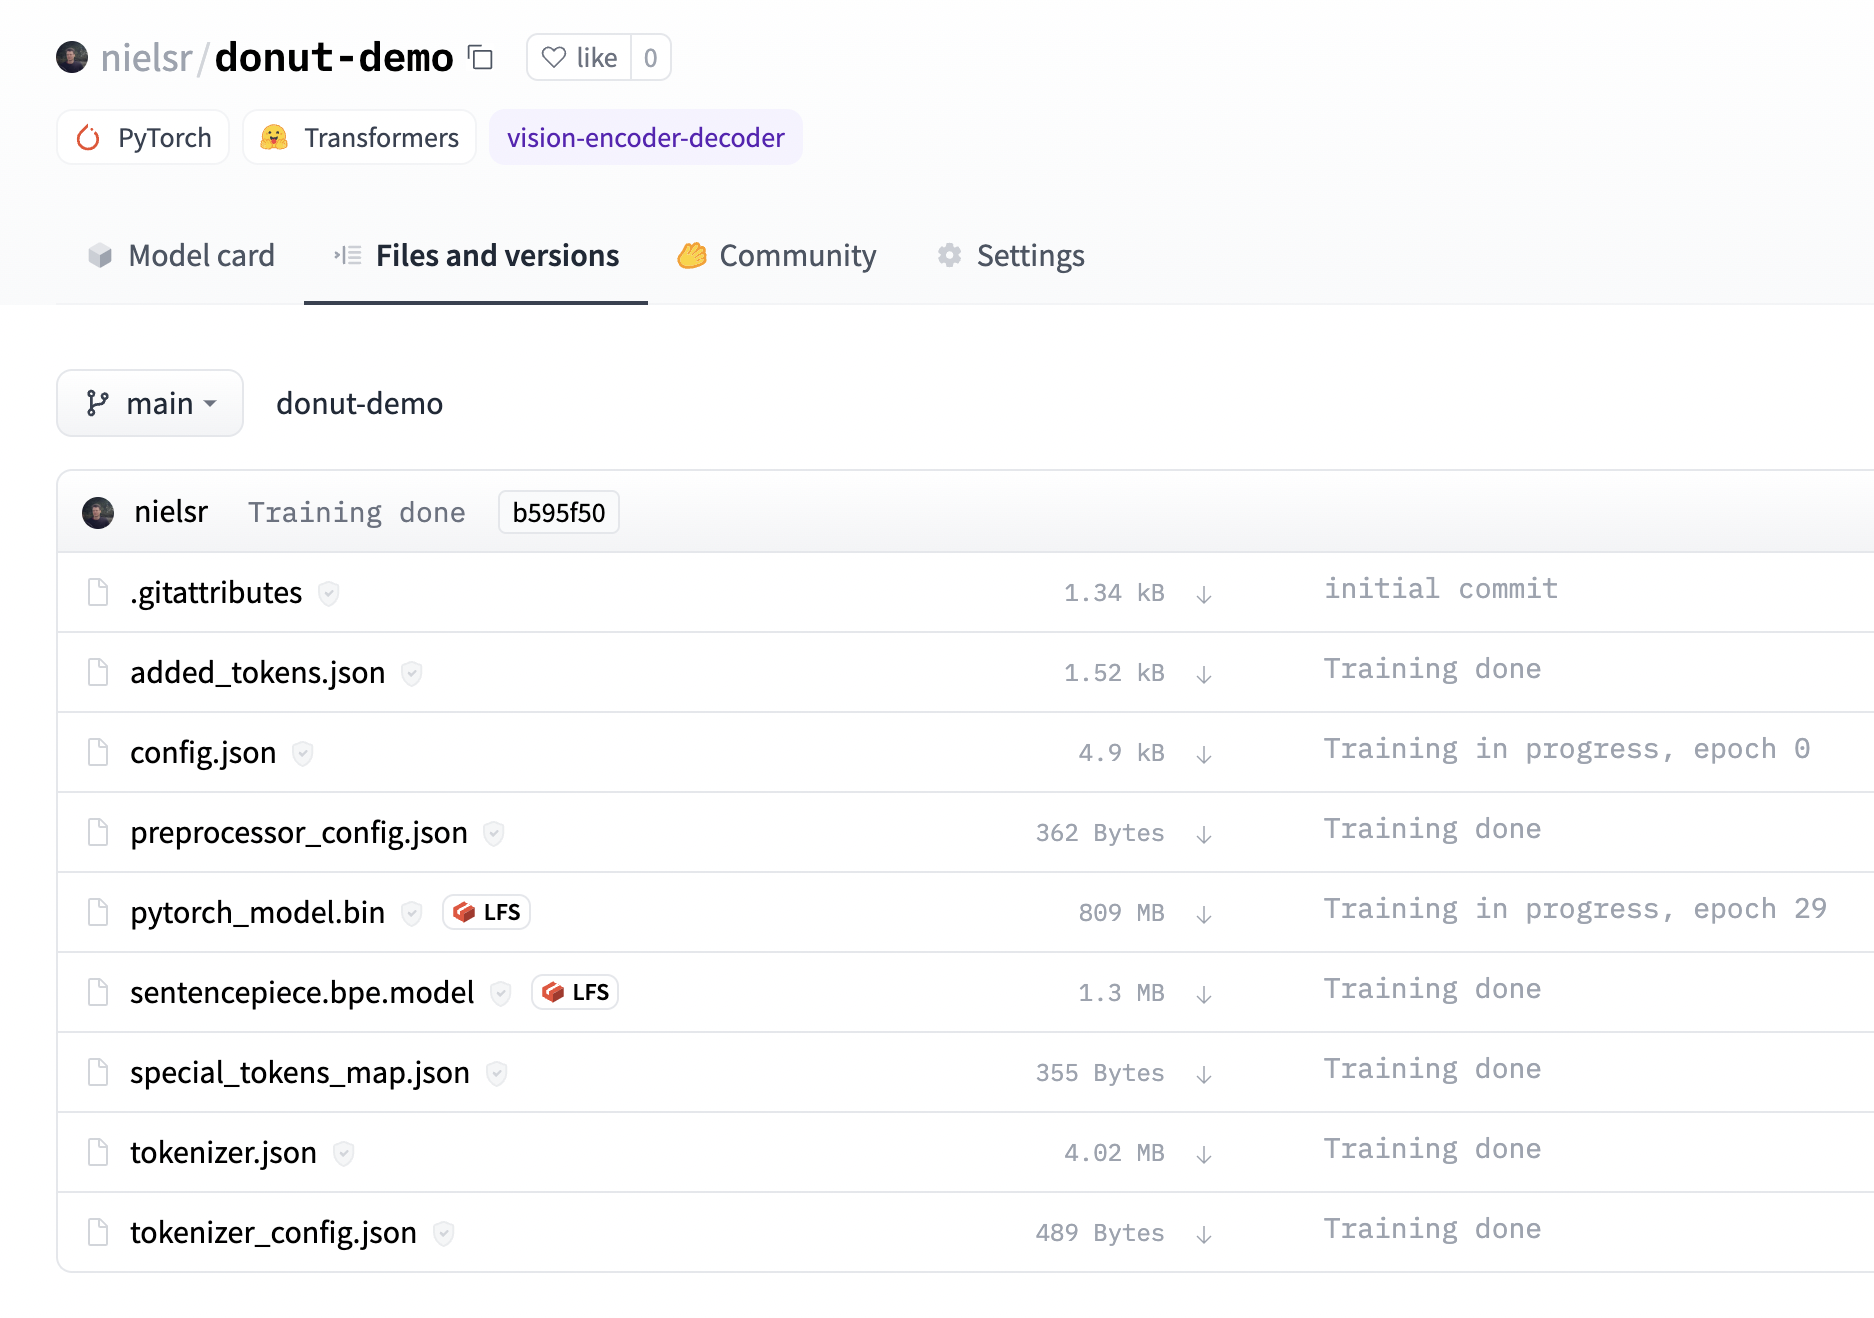

Note that you can also easily refer to a specific commit in the `from_pretrained` method using the [`revision`](https://huggingface.co/docs/transformers/v4.21.1/en/main_classes/model#transformers.PreTrainedModel.from_pretrained.revision) argument, or use the private hub in case you'd like to keep your models private and only shared with certain colleagues for instance.

Here we're just loading from the main branch, which means the latest commit.

In [ ]:
from transformers import DonutProcessor, VisionEncoderDecoderModel

processor = DonutProcessor.from_pretrained("AqsaK/donut_cord")
model = VisionEncoderDecoderModel.from_pretrained("AqsaK/donut_cord")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/421 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/11.7k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.30M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/1.04k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.donut.modeling_donut_swin.DonutSwinModel'> is overwritten by shared encoder config: DonutSwinConfig {
  "attention_probs_dropout_prob": 0.0,
  "depths": [
    2,
    2,
    14,
    2
  ],
  "drop_path_rate": 0.1,
  "embed_dim": 128,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": [
    1280,
    960
  ],
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-05,
  "mlp_ratio": 4.0,
  "model_type": "donut-swin",
  "num_channels": 3,
  "num_heads": [
    4,
    8,
    16,
    32
  ],
  "num_layers": 4,
  "patch_size": 4,
  "path_norm": true,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.50.2",
  "use_absolute_embeddings": false,
  "window_size": 10
}

Config of the decoder: <class 'transformers.models.mbart.modeling_mbart.MBartForCausalLM'> is overwritten by shared decoder config: MBartConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cro

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

As we don't have a test split here, let's evaluate on the validation split.

We'll use the `token2json` method of the processor to turn the generated sequences into JSON, and the `JSONParseEvaluator` object available in the Donut package.

In [ ]:
#test the model on validation data

import re
import json
import torch
from tqdm.auto import tqdm
import numpy as np

from donut import JSONParseEvaluator

from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"

model.eval()
model.to(device)

output_list = []
accs = []

dataset = load_dataset("AqsaK/1880_census_handwritten_archives", split="train")

for idx in tqdm(range(len(dataset))):

# for idx, sample in tqdm(enumerate(dataset), total=len(dataset)):
  try:
      # prepare encoder inputs
      pixel_values = processor(sample["image"].convert("RGB"), return_tensors="pt").pixel_values
      pixel_values = pixel_values.to(device)
      # prepare decoder inputs
      task_prompt = "<s_cord-v2>"
      decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids
      decoder_input_ids = decoder_input_ids.to(device)

      # autoregressively generate sequence
      outputs = model.generate(
              pixel_values,
              decoder_input_ids=decoder_input_ids,
              max_length=model.decoder.config.max_position_embeddings,
              early_stopping=True,
              pad_token_id=processor.tokenizer.pad_token_id,
              eos_token_id=processor.tokenizer.eos_token_id,
              use_cache=True,
              num_beams=1,
              bad_words_ids=[[processor.tokenizer.unk_token_id]],
              return_dict_in_generate=True,
          )

      # turn into JSON
      seq = processor.batch_decode(outputs.sequences)[0]
      seq = seq.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
      seq = re.sub(r"<.*?>", "", seq, count=1).strip()  # remove first task start token
      seq = processor.token2json(seq)

      ground_truth = json.loads(sample["ground_truth"])
      ground_truth = ground_truth["gt_parse"]
      evaluator = JSONParseEvaluator()
      score = evaluator.cal_acc(seq, ground_truth)

      accs.append(score)
      output_list.append(seq)
  except Exception as e:
      print("Exception: ", e)
      continue

scores = {"accuracies": accs, "mean_accuracy": np.mean(accs)}
print(scores, f"length : {len(accs)}")

In [ ]:
!pip install -q donut-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.1/739.1 kB 23.6 MB/s eta 0:00:00


In [ ]:
import re
import json
import torch
from tqdm.auto import tqdm
import numpy as np

from donut import JSONParseEvaluator

from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"

model.eval()
model.to(device)

output_list = []
accs = []

dataset = load_dataset("AqsaK/1880_census_handwritten_archives", split="train")

for idx in tqdm(range(len(dataset))):

# for idx, sample in tqdm(enumerate(dataset), total=len(dataset)):
  try:
      # prepare encoder inputs
      pixel_values = processor(sample["image"].convert("RGB"), return_tensors="pt").pixel_values
      pixel_values = pixel_values.to(device)
      # prepare decoder inputs
      task_prompt = "<s_cord-v2>"
      decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids
      decoder_input_ids = decoder_input_ids.to(device)

      # autoregressively generate sequence
      outputs = model.generate(
              pixel_values,
              decoder_input_ids=decoder_input_ids,
              max_length=model.decoder.config.max_position_embeddings,
              early_stopping=True,
              pad_token_id=processor.tokenizer.pad_token_id,
              eos_token_id=processor.tokenizer.eos_token_id,
              use_cache=True,
              num_beams=1,
              bad_words_ids=[[processor.tokenizer.unk_token_id]],
              return_dict_in_generate=True,
          )

      # turn into JSON
      seq = processor.batch_decode(outputs.sequences)[0]
      seq = seq.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
      seq = re.sub(r"<.*?>", "", seq, count=1).strip()  # remove first task start token
      seq = processor.token2json(seq)

      ground_truth = json.loads(sample["ground_truth"])
      ground_truth = ground_truth["gt_parse"]
      evaluator = JSONParseEvaluator()
      score = evaluator.cal_acc(seq, ground_truth)

      accs.append(score)
      output_list.append(seq)
  except Exception as e:
      print("Exception: ", e)
      continue

scores = {"accuracies": accs, "mean_accuracy": np.mean(accs)}
print(scores, f"length : {len(accs)}")

  0%|          | 0/1595 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x792520f22ca0>

In [ ]:
print("Mean accuracy:", np.mean(accs))